# ML Methods - Volatility Prediction

# Imports

In [26]:
from pathlib import Path
import sys
import gc
import math
import os
import random
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from arch import arch_model
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "exploration" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from technical.labelling import label_volatility

import xgboost as xgb
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.set_num_threads(1)


# Data Loading

In [27]:
SYMBOL = "AAPL"
DATA_DIR = PROJECT_ROOT / "data"
BOOK_PATH = DATA_DIR / f"{SYMBOL}_1s.parquet"
EVENT_PATH = DATA_DIR / f"{SYMBOL}_evt.parquet"

TICK_SIZE = 0.01
HORIZON = 20
SESSION_GAP_SECONDS = 3600
EVENT_FEATURE_LAG_SECONDS = 1
ROLLING_WARMUP = 20
TEST_SESSION_COUNT = 5

book = pd.read_parquet(BOOK_PATH).sort_values("time_abs_s").reset_index(drop=True)
book["time_abs_s"] = book["time_abs_s"].astype(np.int64)

event_cols = ["time_abs_s", "event_type", "size", "direction"]
events = pd.read_parquet(
    EVENT_PATH,
    columns=event_cols,
    filters=[("event_type", "in", [1, 2, 3, 4, 5])],
)
events = events.sort_values("time_abs_s").reset_index(drop=True)
events["time_abs_s"] = events["time_abs_s"].astype(np.int64)
events["event_type"] = events["event_type"].astype(np.int8)
events["direction"] = events["direction"].astype(np.int8)
events["size"] = events["size"].astype(np.float32)


# Feature Engineering

In [28]:
def add_sessions(df):
    out = df.sort_values("time_abs_s").reset_index(drop=True).copy()
    dt = out["time_abs_s"].diff()
    is_new_session = (dt < 0) | (dt > SESSION_GAP_SECONDS)
    out["session_id"] = is_new_session.fillna(False).cumsum().astype(int)
    out["session_pos"] = out.groupby("session_id").cumcount().astype(int)
    out["session_len"] = out.groupby("session_id")["time_abs_s"].transform("size").astype(int)
    out["session_progress"] = (out["session_pos"] / (out["session_len"] - 1)).fillna(0.0).astype(np.float32)
    return out

book = add_sessions(book)


In [29]:
def aggregate_message_features(events):
    evt = events.copy()
    event_type = evt["event_type"].to_numpy(dtype=np.int8)
    direction = evt["direction"].to_numpy(dtype=np.int8)
    size = evt["size"].to_numpy(dtype=np.float32)

    add_mask = event_type == 1
    cancel_mask = np.isin(event_type, [2, 3])
    visible_exec_mask = event_type == 4
    hidden_exec_mask = event_type == 5
    trade_mask = visible_exec_mask | hidden_exec_mask

    evt["limit_add_signed_1s"] = np.where(add_mask, direction * size, 0.0).astype(np.float32)
    evt["limit_add_abs_1s"] = np.where(add_mask, size, 0.0).astype(np.float32)

    evt["cancel_pressure_signed_1s"] = np.where(cancel_mask, -direction * size, 0.0).astype(np.float32)
    evt["cancel_abs_1s"] = np.where(cancel_mask, size, 0.0).astype(np.float32)

    evt["aggr_trade_signed_1s"] = np.where(visible_exec_mask, -direction * size, 0.0).astype(np.float32)
    evt["aggr_trade_abs_1s"] = np.where(visible_exec_mask, size, 0.0).astype(np.float32)

    evt["hidden_trade_signed_1s"] = np.where(hidden_exec_mask, -direction * size, 0.0).astype(np.float32)
    evt["hidden_trade_abs_1s"] = np.where(hidden_exec_mask, size, 0.0).astype(np.float32)

    evt["event_count_1s"] = 1
    evt["trade_count_1s"] = np.where(trade_mask, 1, 0).astype(np.int16)

    message_features = (
        evt.groupby("time_abs_s", sort=True)
        .agg(
            limit_add_signed_1s=("limit_add_signed_1s", "sum"),
            limit_add_abs_1s=("limit_add_abs_1s", "sum"),
            cancel_pressure_signed_1s=("cancel_pressure_signed_1s", "sum"),
            cancel_abs_1s=("cancel_abs_1s", "sum"),
            aggr_trade_signed_1s=("aggr_trade_signed_1s", "sum"),
            aggr_trade_abs_1s=("aggr_trade_abs_1s", "sum"),
            hidden_trade_signed_1s=("hidden_trade_signed_1s", "sum"),
            hidden_trade_abs_1s=("hidden_trade_abs_1s", "sum"),
            event_count_1s=("event_count_1s", "sum"),
            trade_count_1s=("trade_count_1s", "sum"),
        )
        .reset_index()
    )
    message_features["time_abs_s"] = message_features["time_abs_s"] + EVENT_FEATURE_LAG_SECONDS
    return message_features

message_1s = aggregate_message_features(events)
del events
gc.collect()

book = book.merge(message_1s, on="time_abs_s", how="left")
message_cols = [
    "limit_add_signed_1s", "limit_add_abs_1s",
    "cancel_pressure_signed_1s", "cancel_abs_1s",
    "aggr_trade_signed_1s", "aggr_trade_abs_1s",
    "hidden_trade_signed_1s", "hidden_trade_abs_1s",
    "event_count_1s", "trade_count_1s",
]
book[message_cols] = book[message_cols].fillna(0.0)
book["event_count_1s"] = book["event_count_1s"].astype(np.int32)
book["trade_count_1s"] = book["trade_count_1s"].astype(np.int32)
for col in set(message_cols) - {"event_count_1s", "trade_count_1s"}:
    book[col] = book[col].astype(np.float32)


In [30]:
selected_features = [
    "imb_l1",
    "cum_imb_l3",
    "cum_imb_l5",
    "cum_imb_l10",
    "imbalance_gradient_l3_l10",
    "bid_depth_l3",
    "ask_depth_l3",
    "depth_ratio_l3",
    "spread_ticks",
    "one_tick_spread",
    "touch_depth",
    "cum_depth_l3",
    "cum_depth_l5",
    "cum_depth_l10",
    "microprice",
    "microbias_ticks",
    "microbias_over_spread",
    "event_count_3",
    "event_count_10",
    "event_count_20",
    "trade_count_3",
    "trade_count_10",
    "trade_count_20",
    "ofi_l1_norm_w3",
    "ofi_l1_norm_w10",
    "ofi_l1_norm_w20",
    "ofi_change_3",
    "ofi_change_5",
    "ofi_change_20",
    "mid_ret_3",
    "mid_ret_10",
    "mid_ret_20",
    "realized_vol_5",
    "realized_vol_10",
    "realized_vol_20",
    "return_abs_5",
    "sma_10_dist",
    "sma_20_dist",
    "rsi_14",
    "macd",
    "rolling_return_10",
    "rolling_return_20",
    "bb_position_20",
    "bb_width_20",
    "vwap",
]


In [31]:
def rolling_sum_by_session(series, session_id, window):
    if window == 1:
        return series.astype(np.float32)
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .sum()
        .reset_index(level=0, drop=True)
        .fillna(0.0)
        .astype(np.float32)
    )


def rolling_mean_by_session(series, session_id, window):
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .mean()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def rolling_std_by_session(series, session_id, window):
    return (
        series.groupby(session_id, sort=False)
        .rolling(window, min_periods=window)
        .std()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def ewm_mean_by_session(series, session_id, span):
    return (
        series.groupby(session_id, sort=False)
        .ewm(span=span, adjust=False)
        .mean()
        .reset_index(level=0, drop=True)
        .astype(np.float32)
    )


def compute_ofi_level(df, level):
    grouped = df.groupby("session_id", sort=False)
    bid = df[f"bid{level}"].astype(float)
    ask = df[f"ask{level}"].astype(float)
    bid_size = df[f"bid{level}_sz"].astype(float)
    ask_size = df[f"ask{level}_sz"].astype(float)

    previous_bid = grouped[f"bid{level}"].shift(1)
    previous_ask = grouped[f"ask{level}"].shift(1)
    previous_bid_size = grouped[f"bid{level}_sz"].shift(1).fillna(0.0)
    previous_ask_size = grouped[f"ask{level}_sz"].shift(1).fillna(0.0)

    bid_change = bid - previous_bid
    ask_change = ask - previous_ask
    bid_size_change = bid_size - previous_bid_size
    ask_size_change = ask_size - previous_ask_size

    bid_ofi = np.where(bid_change > 0, bid_size, np.where(bid_change < 0, -previous_bid_size, bid_size_change))
    ask_ofi = np.where(ask_change < 0, -ask_size, np.where(ask_change > 0, previous_ask_size, -ask_size_change))
    return pd.Series(bid_ofi + ask_ofi, index=df.index).fillna(0.0).astype(np.float32)


def build_selected_features(df):
    out = df.copy()
    eps = 1e-9

    book_numeric_cols = [
        "mid",
        *[f"bid{i}" for i in range(1, 11)],
        *[f"ask{i}" for i in range(1, 11)],
        *[f"bid{i}_sz" for i in range(1, 11)],
        *[f"ask{i}_sz" for i in range(1, 11)],
    ]
    out[book_numeric_cols] = out[book_numeric_cols].apply(pd.to_numeric, errors="coerce").astype(np.float32)
    out["mid"] = out["mid"].fillna((out["bid1"] + out["ask1"]) * 0.5).astype(np.float32)

    grouped = out.groupby("session_id", sort=False)

    out["spread"] = (out["ask1"] - out["bid1"]).astype(np.float32)
    out["spread_ticks"] = (out["spread"] / TICK_SIZE).astype(np.float32)
    out["one_tick_spread"] = (out["spread_ticks"] <= 1.01).astype(np.float32)

    out["touch_depth"] = (out["bid1_sz"] + out["ask1_sz"]).astype(np.float32)
    out["imb_l1"] = ((out["bid1_sz"] - out["ask1_sz"]) / (out["touch_depth"] + eps)).astype(np.float32)

    out["bid_depth_l3"] = out[["bid1_sz", "bid2_sz", "bid3_sz"]].sum(axis=1).astype(np.float32)
    out["ask_depth_l3"] = out[["ask1_sz", "ask2_sz", "ask3_sz"]].sum(axis=1).astype(np.float32)
    bid_depth_l5 = out[[f"bid{i}_sz" for i in range(1, 6)]].sum(axis=1).astype(np.float32)
    ask_depth_l5 = out[[f"ask{i}_sz" for i in range(1, 6)]].sum(axis=1).astype(np.float32)
    bid_depth_l10 = out[[f"bid{i}_sz" for i in range(1, 11)]].sum(axis=1).astype(np.float32)
    ask_depth_l10 = out[[f"ask{i}_sz" for i in range(1, 11)]].sum(axis=1).astype(np.float32)

    out["cum_depth_l3"] = (out["bid_depth_l3"] + out["ask_depth_l3"]).astype(np.float32)
    out["cum_depth_l5"] = (bid_depth_l5 + ask_depth_l5).astype(np.float32)
    out["cum_depth_l10"] = (bid_depth_l10 + ask_depth_l10).astype(np.float32)

    out["cum_imb_l3"] = ((out["bid_depth_l3"] - out["ask_depth_l3"]) / (out["cum_depth_l3"] + eps)).astype(np.float32)
    out["cum_imb_l5"] = ((bid_depth_l5 - ask_depth_l5) / (out["cum_depth_l5"] + eps)).astype(np.float32)
    out["cum_imb_l10"] = ((bid_depth_l10 - ask_depth_l10) / (out["cum_depth_l10"] + eps)).astype(np.float32)
    out["imbalance_gradient_l3_l10"] = (out["cum_imb_l3"] - out["cum_imb_l10"]).astype(np.float32)
    out["depth_ratio_l3"] = (out["bid_depth_l3"] / (out["ask_depth_l3"] + eps)).astype(np.float32)

    out["microprice"] = (
        (out["bid1"] * out["ask1_sz"] + out["ask1"] * out["bid1_sz"])
        / (out["touch_depth"] + eps)
    ).astype(np.float32)
    out["microbias_ticks"] = ((out["microprice"] - out["mid"]) / TICK_SIZE).astype(np.float32)
    out["microbias_over_spread"] = (
        (out["microprice"] - out["mid"]) / (out["spread"] + eps)
    ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    out["event_count_1"] = out["event_count_1s"].astype(np.float32)
    out["trade_count_1"] = out["trade_count_1s"].astype(np.float32)
    for window in [3, 10, 20]:
        out[f"event_count_{window}"] = rolling_sum_by_session(out["event_count_1"], out["session_id"], window)
        out[f"trade_count_{window}"] = rolling_sum_by_session(out["trade_count_1"], out["session_id"], window)

    out["ofi_l1_raw"] = compute_ofi_level(out, 1)
    for window in [3, 10, 20]:
        ofi_sum = rolling_sum_by_session(out["ofi_l1_raw"], out["session_id"], window)
        out[f"ofi_l1_norm_w{window}"] = (
            ofi_sum / (out["touch_depth"] + eps)
        ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    for window in [3, 5, 20]:
        previous_ofi = grouped["ofi_l1_raw"].shift(window).fillna(0.0)
        out[f"ofi_change_{window}"] = (
            (out["ofi_l1_raw"] - previous_ofi) / (out["touch_depth"] + eps)
        ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    log_mid = np.log(out["mid"].astype(float).clip(lower=eps))
    out["mid_ret_1"] = (
        log_mid.groupby(out["session_id"])
        .diff()
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )
    for window in [3, 10, 20]:
        out[f"mid_ret_{window}"] = rolling_sum_by_session(out["mid_ret_1"], out["session_id"], window)
        out[f"rolling_return_{window}"] = out[f"mid_ret_{window}"].astype(np.float32)

    out["realized_vol_5"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 5)
    ).astype(np.float32)
    out["realized_vol_10"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 10)
    ).astype(np.float32)
    out["realized_vol_20"] = np.sqrt(
        rolling_sum_by_session(out["mid_ret_1"].astype(float) ** 2, out["session_id"], 20)
    ).astype(np.float32)
    out["return_abs_5"] = rolling_sum_by_session(out["mid_ret_1"].abs(), out["session_id"], 5)

    sma_10 = rolling_mean_by_session(out["mid"], out["session_id"], 10)
    sma_20 = rolling_mean_by_session(out["mid"], out["session_id"], 20)
    out["sma_10_dist"] = ((out["mid"] - sma_10) / (sma_10 + eps)).astype(np.float32)
    out["sma_20_dist"] = ((out["mid"] - sma_20) / (sma_20 + eps)).astype(np.float32)

    price_change = grouped["mid"].diff().fillna(0.0)
    gain = price_change.clip(lower=0.0)
    loss = (-price_change).clip(lower=0.0)
    avg_gain = rolling_mean_by_session(gain, out["session_id"], 14)
    avg_loss = rolling_mean_by_session(loss, out["session_id"], 14)
    rs = avg_gain / (avg_loss + eps)
    out["rsi_14"] = (100.0 - (100.0 / (1.0 + rs))).fillna(50.0).astype(np.float32)

    ema_12 = ewm_mean_by_session(out["mid"], out["session_id"], 12)
    ema_26 = ewm_mean_by_session(out["mid"], out["session_id"], 26)
    out["macd"] = (ema_12 - ema_26).astype(np.float32)

    bb_mean_20 = sma_20
    bb_std_20 = rolling_std_by_session(out["mid"], out["session_id"], 20)
    bb_upper_20 = bb_mean_20 + 2.0 * bb_std_20
    bb_lower_20 = bb_mean_20 - 2.0 * bb_std_20
    out["bb_position_20"] = (
        (out["mid"] - bb_lower_20) / (bb_upper_20 - bb_lower_20 + eps)
    ).replace([np.inf, -np.inf], 0.5).fillna(0.5).astype(np.float32)
    out["bb_width_20"] = (
        (bb_upper_20 - bb_lower_20) / (out["mid"].abs() + eps)
    ).replace([np.inf, -np.inf], 0.0).fillna(0.0).astype(np.float32)

    trade_volume_1 = (out["aggr_trade_abs_1s"] + out["hidden_trade_abs_1s"]).astype(np.float32)
    vwap_num = rolling_sum_by_session(out["mid"] * trade_volume_1, out["session_id"], 20)
    vwap_den = rolling_sum_by_session(trade_volume_1, out["session_id"], 20)
    out["vwap"] = (vwap_num / vwap_den.replace(0.0, np.nan)).fillna(sma_20).fillna(out["mid"]).astype(np.float32)

    out[selected_features] = (
        out[selected_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )
    return out

book = build_selected_features(book)


# Target Construction

In [32]:
def label_one_session(session_df):
    labeled = label_volatility(
        session_df,
        close_col="mid",
        horizon=HORIZON,
        out_col="y_vol",
    )
    return labeled[labeled["session_pos"] < labeled["session_len"] - HORIZON]

book = (
    book.groupby("session_id", group_keys=False, sort=False)
    .apply(label_one_session)
    .reset_index(drop=True)
)

book["observed_y_vol"] = book.groupby("session_id", sort=False)["y_vol"].shift(HORIZON)
book["har_vol_1"] = book["observed_y_vol"].astype(np.float32)
book["har_vol_5"] = (
    book.groupby("session_id", sort=False)["observed_y_vol"]
    .rolling(5, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .astype(np.float32)
)
book["har_vol_20"] = (
    book.groupby("session_id", sort=False)["observed_y_vol"]
    .rolling(20, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
    .astype(np.float32)
)

model_df = book[
    (book["session_pos"] >= ROLLING_WARMUP)
    & book["y_vol"].notna()
    & book["observed_y_vol"].notna()
].copy().reset_index(drop=True)
model_df["y_vol"] = model_df["y_vol"].astype(np.float32)


# Train/Test Split

In [33]:
def qlike_loss(y_true, y_pred, eps=1e-12):
    y_true_var = np.maximum(np.asarray(y_true, dtype=float) ** 2, eps)
    y_pred_var = np.maximum(np.asarray(y_pred, dtype=float) ** 2, eps)
    ratio = y_true_var / y_pred_var
    return float(np.mean(ratio - np.log(ratio) - 1.0))


def regression_metrics(model_name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0.0)
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "QLIKE": qlike_loss(y_true, y_pred),
    }


def save_predictions(model_name, predictions):
    prediction_df[model_name] = np.maximum(np.asarray(predictions, dtype=float), 0.0)
    row = regression_metrics(model_name, y_test, prediction_df[model_name])
    results.append(row)
    display(pd.DataFrame([row]))


In [34]:
sessions = sorted(model_df["session_id"].unique())
test_sessions = sessions[-TEST_SESSION_COUNT:]
train_sessions = sessions[:-TEST_SESSION_COUNT]

model_df["split"] = np.where(model_df["session_id"].isin(test_sessions), "test", "train")

train_df = model_df[model_df["split"] == "train"].copy().reset_index(drop=True)
test_df = model_df[model_df["split"] == "test"].copy().reset_index(drop=True)

X_train = train_df[selected_features]
y_train = train_df["y_vol"].to_numpy(dtype=np.float32)
X_test = test_df[selected_features]
y_test = test_df["y_vol"].to_numpy(dtype=np.float32)

prediction_df = test_df[["time_abs_s", "session_id", "session_pos", "y_vol"]].copy().reset_index(drop=True)
results = []


# Naive Carry-Forward Baseline

In [35]:
naive_baseline_name = "Naive Carry-Forward"


In [36]:
naive_pred = test_df["observed_y_vol"].to_numpy(dtype=np.float32)
save_predictions(naive_baseline_name, naive_pred)


,model,MAE,RMSE,R2,QLIKE
0,Naive Carry-Forward,0.00011,0.000176,0.076706,0.475311


# HAR

In [37]:
har_features = ["har_vol_1", "har_vol_5", "har_vol_20"]


In [38]:
har_model = LinearRegression()
har_model.fit(train_df[har_features], y_train)
har_pred = har_model.predict(test_df[har_features])
save_predictions("HAR", har_pred)


,model,MAE,RMSE,R2,QLIKE
0,HAR,0.000094,0.00015,0.334556,0.305629


# GARCH

In [39]:
garch_scale = 10000.0
garch_p = 1
garch_q = 1


In [40]:
garch_train_returns = train_df["mid_ret_1"].to_numpy(dtype=float) * garch_scale
garch_train_returns = garch_train_returns[np.isfinite(garch_train_returns)]

garch_model = arch_model(
    garch_train_returns,
    mean="Zero",
    vol="GARCH",
    p=garch_p,
    q=garch_q,
    dist="normal",
    rescale=False,
)
garch_fit = garch_model.fit(disp="off", update_freq=0)

omega = float(garch_fit.params["omega"])
alpha = float(garch_fit.params["alpha[1]"])
beta = float(garch_fit.params["beta[1]"])
last_variance = float(np.asarray(garch_fit.conditional_volatility)[-1] ** 2)

garch_pred = []
for current_return in test_df["mid_ret_1"].to_numpy(dtype=float) * garch_scale:
    last_variance = omega + alpha * current_return ** 2 + beta * last_variance
    future_variance = last_variance
    horizon_variances = []
    for step in range(HORIZON):
        horizon_variances.append(future_variance)
        future_variance = omega + (alpha + beta) * future_variance
    garch_pred.append(math.sqrt(sum(horizon_variances)) / garch_scale)

save_predictions("GARCH(1,1)", garch_pred)


,model,MAE,RMSE,R2,QLIKE
0,"GARCH(1,1)",0.000109,0.000157,0.270995,0.303962


# Linear Regression

In [41]:
linear_regression_name = "Linear Regression"


In [42]:
linear_scaler = StandardScaler()
X_train_linear = linear_scaler.fit_transform(X_train)
X_test_linear = linear_scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train_linear, y_train)
linear_pred = linear_model.predict(X_test_linear)
save_predictions(linear_regression_name, linear_pred)


,model,MAE,RMSE,R2,QLIKE
0,Linear Regression,0.000094,0.000148,0.34751,0.323982


# Random Forest

In [43]:
rf_n_estimators = 200
rf_max_depth = 8
rf_min_samples_leaf = 20


In [44]:
rf_model = RandomForestRegressor(
    n_estimators=rf_n_estimators,
    max_depth=rf_max_depth,
    min_samples_leaf=rf_min_samples_leaf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
save_predictions("Random Forest", rf_pred)


,model,MAE,RMSE,R2,QLIKE
0,Random Forest,0.000098,0.00015,0.329827,0.314947


# XGBoost

In [45]:
xgb_params = dict(
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    reg_alpha=0.0,
    gamma=0.0,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbosity=0,
)


In [46]:
xgb_model = xgb.XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
save_predictions("XGBoost", xgb_pred)


,model,MAE,RMSE,R2,QLIKE
0,XGBoost,0.000097,0.000149,0.338387,0.308633


# LSTM

In [47]:
lstm_sequence_length = 20
lstm_hidden_size = 32
lstm_batch_size = 512
lstm_epochs = 50
lstm_patience = 5
lstm_learning_rate = 0.001


In [48]:
def make_lstm_sequences(df, X_values, y_values, sequence_length):
    X_sequences = []
    y_sequences = []
    row_numbers = []
    session_values = df["session_id"].to_numpy()

    for session_id in df["session_id"].unique():
        rows = np.where(session_values == session_id)[0]
        session_X = X_values[rows]
        session_y = y_values[rows]

        for i in range(sequence_length - 1, len(session_X)):
            X_sequences.append(session_X[i - sequence_length + 1:i + 1])
            y_sequences.append(session_y[i])
            row_numbers.append(rows[i])

    return (
        np.array(X_sequences, dtype=np.float32),
        np.array(y_sequences, dtype=np.float32),
        np.array(row_numbers, dtype=np.int64),
    )

lstm_scaler = StandardScaler()
X_train_lstm_scaled = lstm_scaler.fit_transform(X_train).astype(np.float32)
X_test_lstm_scaled = lstm_scaler.transform(X_test).astype(np.float32)

X_train_lstm, y_train_lstm, train_lstm_rows = make_lstm_sequences(
    train_df,
    X_train_lstm_scaled,
    y_train,
    lstm_sequence_length,
)
X_test_lstm, y_test_lstm, test_lstm_rows = make_lstm_sequences(
    test_df,
    X_test_lstm_scaled,
    y_test,
    lstm_sequence_length,
)

y_lstm_scaler = StandardScaler()
y_train_lstm_scaled = y_lstm_scaler.fit_transform(y_train_lstm.reshape(-1, 1)).ravel().astype(np.float32)

validation_start = int(len(X_train_lstm) * 0.8)
X_lstm_fit = X_train_lstm[:validation_start]
y_lstm_fit = y_train_lstm_scaled[:validation_start]
X_lstm_val = X_train_lstm[validation_start:]
y_lstm_val = y_train_lstm_scaled[validation_start:]

train_dataset = TensorDataset(
    torch.tensor(X_lstm_fit, dtype=torch.float32),
    torch.tensor(y_lstm_fit, dtype=torch.float32),
)
validation_dataset = TensorDataset(
    torch.tensor(X_lstm_val, dtype=torch.float32),
    torch.tensor(y_lstm_val, dtype=torch.float32),
)
train_loader = DataLoader(train_dataset, batch_size=lstm_batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=lstm_batch_size, shuffle=False)

lstm_layer = nn.LSTM(
    input_size=len(selected_features),
    hidden_size=lstm_hidden_size,
    batch_first=True,
)
lstm_output_layer = nn.Linear(lstm_hidden_size, 1)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(lstm_layer.parameters()) + list(lstm_output_layer.parameters()),
    lr=lstm_learning_rate,
)

best_validation_loss = np.inf
best_lstm_state = None
best_output_state = None
epochs_without_improvement = 0

for epoch in range(lstm_epochs):
    lstm_layer.train()
    lstm_output_layer.train()

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        lstm_output, _ = lstm_layer(batch_X)
        pred = lstm_output_layer(lstm_output[:, -1, :]).squeeze(1)
        loss = loss_function(pred, batch_y)
        loss.backward()
        optimizer.step()

    lstm_layer.eval()
    lstm_output_layer.eval()
    validation_losses = []

    with torch.no_grad():
        for batch_X, batch_y in validation_loader:
            lstm_output, _ = lstm_layer(batch_X)
            pred = lstm_output_layer(lstm_output[:, -1, :]).squeeze(1)
            validation_loss = loss_function(pred, batch_y)
            validation_losses.append(validation_loss.item())

    mean_validation_loss = float(np.mean(validation_losses))

    if mean_validation_loss < best_validation_loss:
        best_validation_loss = mean_validation_loss
        best_lstm_state = {key: value.detach().clone() for key, value in lstm_layer.state_dict().items()}
        best_output_state = {key: value.detach().clone() for key, value in lstm_output_layer.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= lstm_patience:
        break

lstm_layer.load_state_dict(best_lstm_state)
lstm_output_layer.load_state_dict(best_output_state)

lstm_layer.eval()
lstm_output_layer.eval()

lstm_predictions_scaled = []
test_dataset = TensorDataset(torch.tensor(X_test_lstm, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=lstm_batch_size, shuffle=False)

with torch.no_grad():
    for (batch_X,) in test_loader:
        lstm_output, _ = lstm_layer(batch_X)
        pred_scaled = lstm_output_layer(lstm_output[:, -1, :]).squeeze(1).numpy()
        lstm_predictions_scaled.append(pred_scaled)

lstm_pred_scaled = np.concatenate(lstm_predictions_scaled)
lstm_pred = y_lstm_scaler.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).ravel()
lstm_pred = np.maximum(lstm_pred, 0.0)

prediction_df["LSTM"] = np.nan
prediction_df.loc[test_lstm_rows, "LSTM"] = lstm_pred

lstm_row = regression_metrics("LSTM", y_test_lstm, lstm_pred)
results.append(lstm_row)
display(pd.DataFrame([lstm_row]))


,model,MAE,RMSE,R2,QLIKE
0,LSTM,0.000091,0.000144,0.374398,0.302761


# Final Comparison

In [49]:
final_comparison = pd.DataFrame(results)
display(final_comparison)


,model,MAE,RMSE,R2,QLIKE
0,Naive Carry-Forward,0.000110,0.000176,0.076706,0.475311
1,HAR,0.000094,0.000150,0.334556,0.305629
2,"GARCH(1,1)",0.000109,0.000157,0.270995,0.303962
3,Linear Regression,0.000094,0.000148,0.347510,0.323982
4,Random Forest,0.000098,0.000150,0.329827,0.314947
5,XGBoost,0.000097,0.000149,0.338387,0.308633
6,LSTM,0.000091,0.000144,0.374398,0.302761


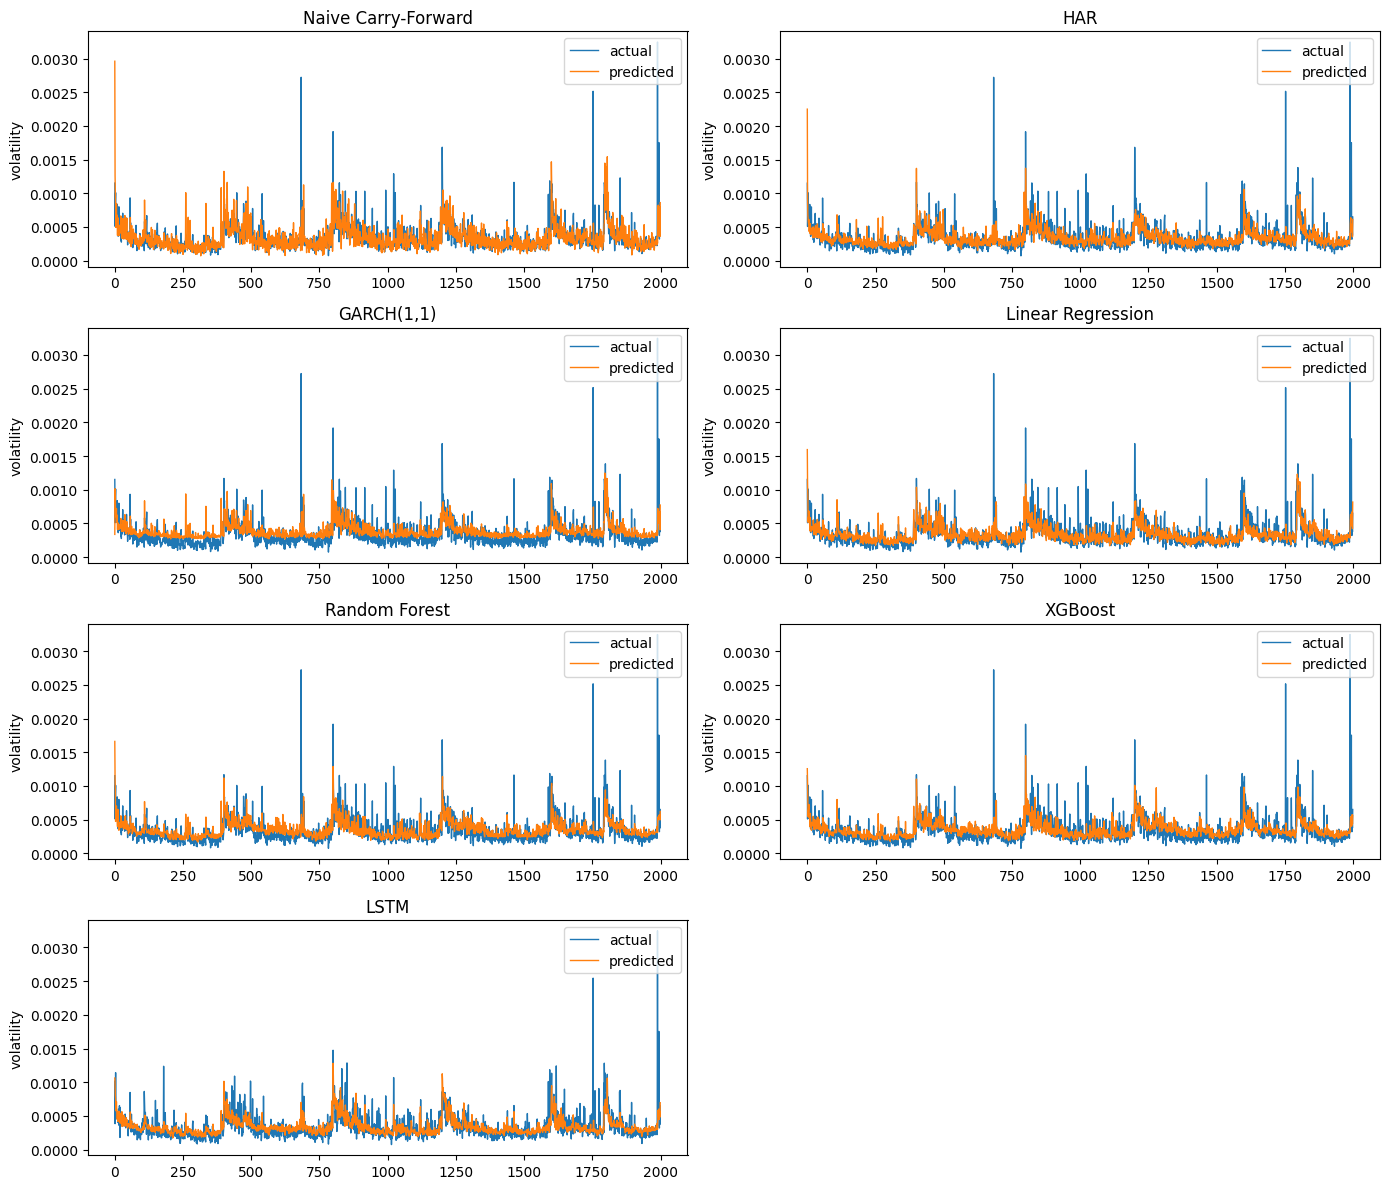

In [50]:
plot_methods = [
    "Naive Carry-Forward",
    "HAR",
    "GARCH(1,1)",
    "Linear Regression",
    "Random Forest",
    "XGBoost",
    "LSTM",
]
plot_max_points = 2000

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=False)
axes = axes.ravel()

for ax, model_name in zip(axes, plot_methods):
    plot_df = prediction_df[["y_vol", model_name]].dropna().reset_index(drop=True)
    if len(plot_df) > plot_max_points:
        rows = np.linspace(0, len(plot_df) - 1, plot_max_points).astype(int)
        plot_df = plot_df.iloc[rows].reset_index(drop=True)

    ax.plot(plot_df["y_vol"].to_numpy(), label="actual", linewidth=1.0)
    ax.plot(plot_df[model_name].to_numpy(), label="predicted", linewidth=1.0)
    ax.set_title(model_name)
    ax.set_ylabel("volatility")
    ax.legend(loc="upper right")

axes[-1].axis("off")
plt.tight_layout()
plt.show()
